In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv(r"c:\Users\HP\Downloads\Eartquakes-1990-2023.csv\Eartquakes-1990-2023.csv")
df

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
3445746,1690626851941,"5 km NW of Chikusei, Japan",reviewed,0,326,earthquake,4.60,Japan,139.940200,36.350700,83.039,2023-07-29 10:34:11.941000+00:00
3445747,1690626975715,"Kodiak Island region, Alaska",automatic,0,44,earthquake,1.70,Alaska,-153.729900,57.790100,24.400,2023-07-29 10:36:15.715000+00:00
3445748,1690627215940,"12 km W of Alberto Oviedo Mota, B.C., MX",automatic,0,90,earthquake,2.42,B.C.,-115.296833,32.233167,1.770,2023-07-29 10:40:15.940000+00:00
3445749,1690628146040,"7 km W of Cobb, CA",automatic,0,16,earthquake,1.03,California,-122.800499,38.827499,1.720,2023-07-29 10:55:46.040000+00:00


1

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement
df = pd.read_csv(r"c:\Users\HP\Downloads\Eartquakes-1990-2023.csv\Eartquakes-1990-2023.csv")

# 2. Conversion robuste et extraction de la DATE uniquement
# 'mixed' permet de gérer les variations de format si elles existent
df['date_full'] = pd.to_datetime(df['date'], format='ISO8601')
df['date_only'] = df['date_full'].dt.date  # On ne garde que YYYY-MM-DD

# 3. Création des colonnes pour la saisonnalité
df['annee'] = df['date_full'].dt.year
df['mois_num'] = df['date_full'].dt.month

# 4. Agrégation (Nombre de séismes par mois/année)
df_counts = df.groupby(['annee', 'mois_num']).size().reset_index(name='nb_seismes')

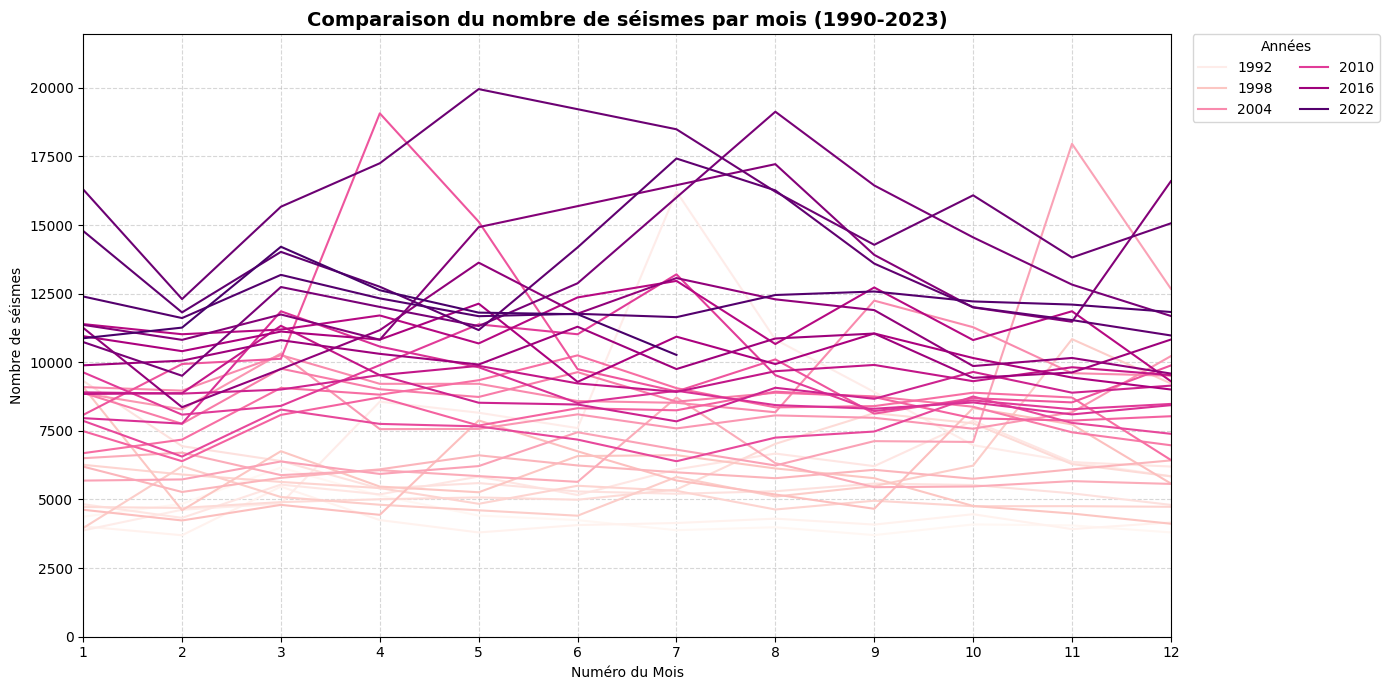

In [17]:
plt.figure(figsize=(14, 7)) # On élargit un peu pour faire de la place à la légende

# 1. Tracé avec la palette demandée (RdPu) et activation de la légende
sns.lineplot(data=df_counts, x='mois_num', y='nb_seismes', hue='annee', palette='RdPu')

# 2. Configuration de l'échelle (Y-axis)
y_max = df_counts['nb_seismes'].max()
plt.ylim(0, y_max * 1.1)
plt.xlim(1, 12)

# 3. Titres et labels
plt.title('Comparaison du nombre de séismes par mois (1990-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Numéro du Mois')
plt.ylabel('Nombre de séismes')
plt.xticks(range(1, 13))

# 4. AJOUT DE LA LÉGENDE (Placée à droite, à l'extérieur du graphique)
plt.legend(title='Années', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., ncol=2)
# Note : ncol=2 permet d'afficher les années sur deux colonnes pour gagner de la hauteur

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout() # Ajuste automatiquement les marges pour que la légende ne soit pas coupée
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_2904\911625323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_counts, x='mois_num', y='nb_seismes', palette='Set2')


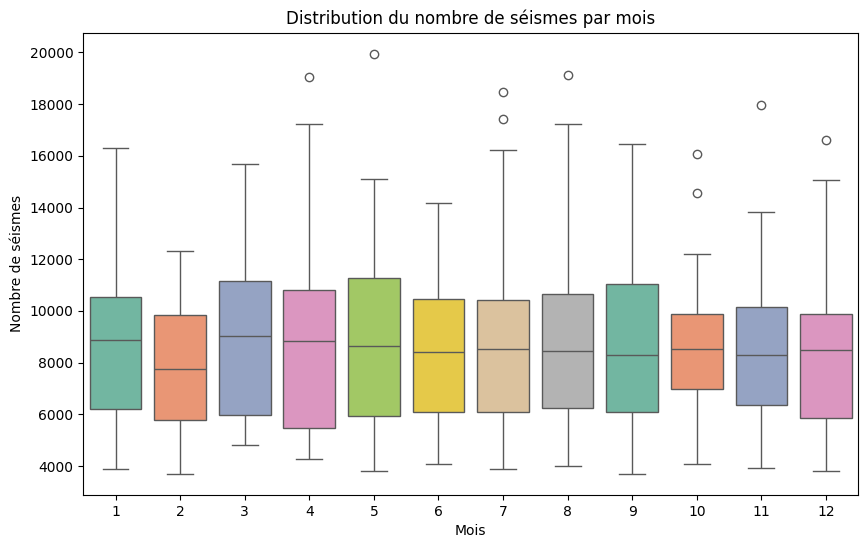

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_counts, x='mois_num', y='nb_seismes', palette='Set2')
plt.title('Distribution du nombre de séismes par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre de séismes')
plt.show()

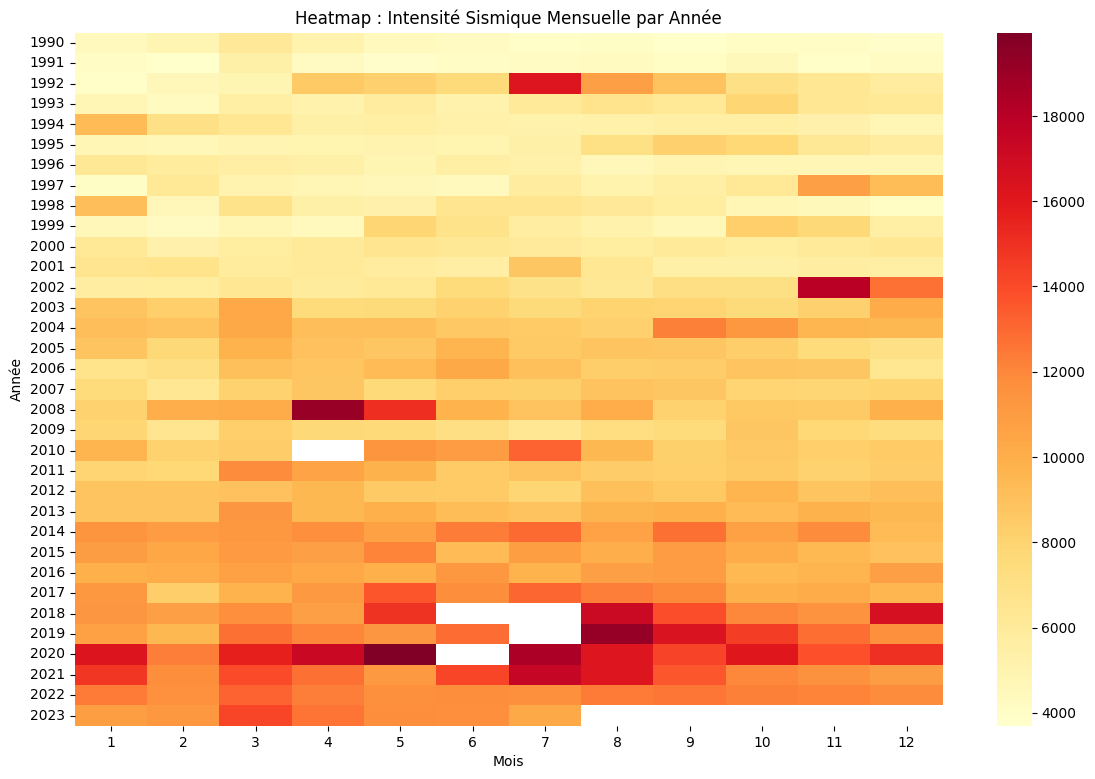

In [11]:
# Transformation pour la heatmap
df_pivot = df_counts.pivot(index="annee", columns="mois_num", values="nb_seismes")

plt.figure(figsize=(14, 9))
sns.heatmap(df_pivot, cmap='YlOrRd', annot=False)
plt.title('Heatmap : Intensité Sismique Mensuelle par Année')
plt.xlabel('Mois')
plt.ylabel('Année')
plt.show()

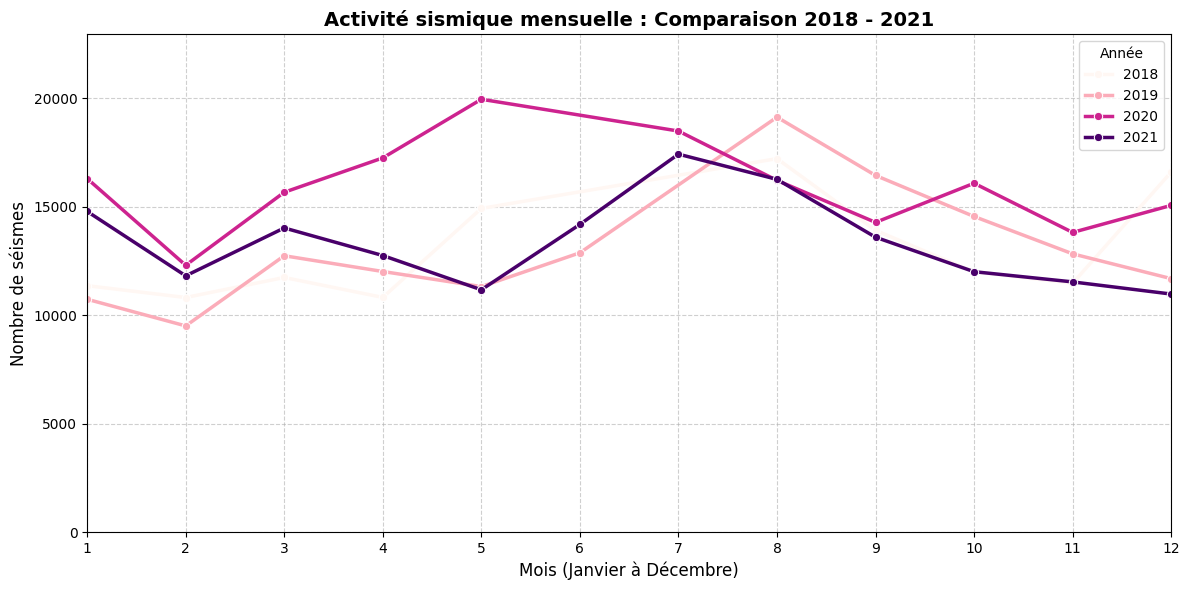

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrage des données pour les années spécifiques
annees_selectionnees = [2018, 2019, 2020, 2021]
df_filtre = df_counts[df_counts['annee'].isin(annees_selectionnees)]

# 2. Création de la figure
plt.figure(figsize=(12, 6))

# 3. Tracé avec la palette RdPu (dégradés de rose/violet)
# On utilise df_filtre au lieu de df_counts
sns.lineplot(data=df_filtre, x='mois_num', y='nb_seismes', 
             hue='annee', palette='RdPu', marker='o', linewidth=2.5)

# 4. Gestion de l'échelle (Adaptée aux données filtrées)
y_max = df_filtre['nb_seismes'].max()
plt.ylim(0, y_max * 1.15) # +15% de marge en haut
plt.xlim(1, 12)

# 5. Titres et labels
plt.title('Activité sismique mensuelle : Comparaison 2018 - 2021', fontsize=14, fontweight='bold')
plt.xlabel('Mois (Janvier à Décembre)', fontsize=12)
plt.ylabel('Nombre de séismes', fontsize=12)
plt.xticks(range(1, 13))

# 6. Ajout de la légende (à l'intérieur cette fois car il y a peu d'années)
plt.legend(title='Année', loc='upper right', frameon=True)

# 7. Grille de lecture
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


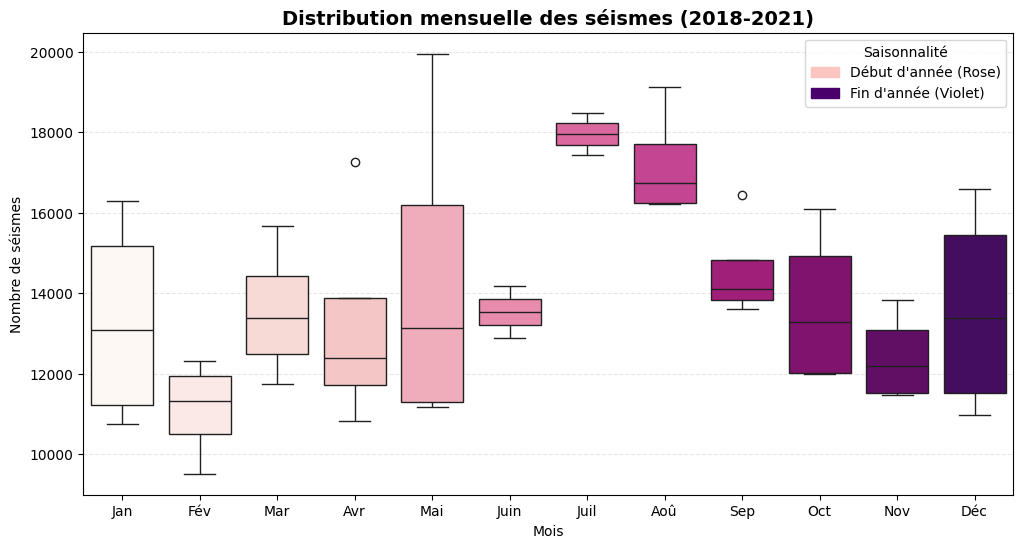

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Filtrage
annees_selectionnees = [2018, 2019, 2020, 2021]
df_filtre = df_counts[df_counts['annee'].isin(annees_selectionnees)]

plt.figure(figsize=(12, 6))

# 2. Création du Boxplot avec HUE pour activer la légende
# On met hue='mois_num' pour que Seaborn associe une couleur à chaque mois
sns.boxplot(data=df_filtre, x='mois_num', y='nb_seismes', hue='mois_num', palette='RdPu', legend=False)

# 3. Paramétrage des axes
plt.title('Distribution mensuelle des séismes (2018-2021)', fontsize=14, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Nombre de séismes')

# On remplace les numéros par les noms des mois
mois_noms = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Aoû", "Sep", "Oct", "Nov", "Déc"]
plt.xticks(range(0, 12), mois_noms)

# 4. AJOUT DE L'AGENDE (Légende personnalisée pour le dégradé)
# Comme on a 12 mois, une légende avec 12 carrés serait trop lourde. 
# On crée une légende qui explique le dégradé de couleur (Rose -> Purple)
patch_debut = mpatches.Patch(color='#fcc5c0', label='Début d\'année (Rose)')
patch_fin = mpatches.Patch(color='#49006a', label='Fin d\'année (Violet)')

plt.legend(handles=[patch_debut, patch_fin], title="Saisonnalité", loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

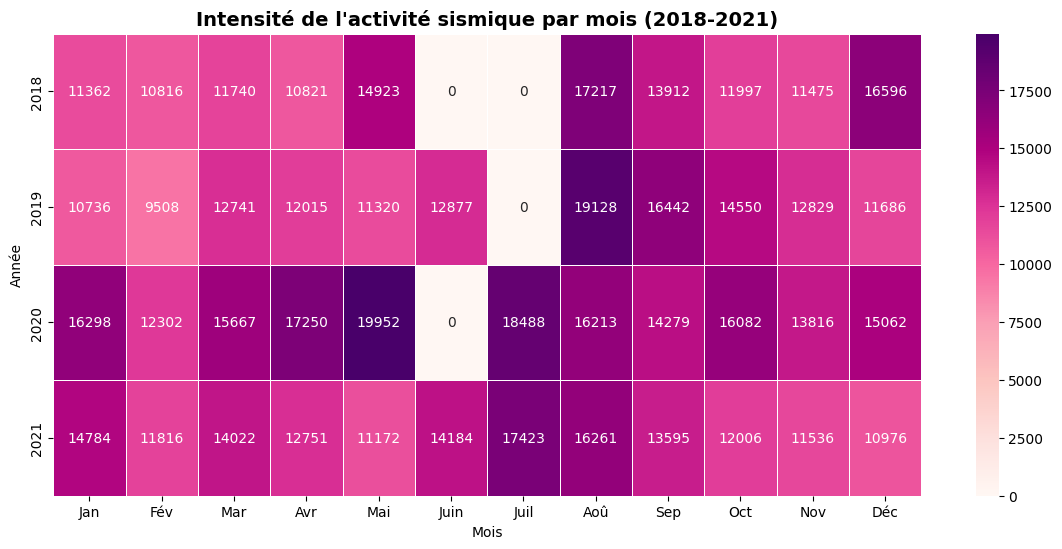

In [21]:
# 1. Remplir les mois vides par 0 et convertir en entier
df_pivot_filtre = df_pivot_filtre.fillna(0).astype(int)

# 2. Maintenant fmt='d' fonctionnera parfaitement
plt.figure(figsize=(14, 6))
sns.heatmap(df_pivot_filtre, cmap='RdPu', annot=True, fmt='d', linewidths=.5)

plt.title('Intensité de l\'activité sismique par mois (2018-2021)', fontsize=14, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Année')
plt.xticks(ticks=[x + 0.5 for x in range(12)], labels=["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Aoû", "Sep", "Oct", "Nov", "Déc"])
plt.show()